# 📊 TelecomX – Machine Learning for Churn Prediction

**Author:** Adriely Lopes  
**Dataset:** TelecomX – Processed Data (Part 1)

This project applies Machine Learning techniques to predict customer churn in a telecommunications company.

The dataset used in this analysis was previously prepared through an **ETL process (Extract, Transform, Load)**, ensuring data quality and consistency before model development.

The goal is to identify patterns associated with customer cancellation and **build predictive models capable of detecting clients at risk of leaving**. These insights can support data-driven decisions and help companies improve customer retention strategies.

🔎 **Previous Project – ETL and Data Preparation**  
[TelecomX Churn ETL Repository](https://github.com/Adrilopes/telecomx-churn-analysis)

___
## 1. Data Preparation

### 1.1 Loading the Processed Dataset and Initial Checks

In [1]:
import pandas as pd

data = pd.read_csv("../data/churn_tratado.csv")
data.head()

,customer_id,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [2]:
data.shape

(7032, 21)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       7032 non-null   str    
 1   churn             7032 non-null   int64  
 2   gender            7032 non-null   str    
 3   seniorcitizen     7032 non-null   int64  
 4   partner           7032 non-null   int64  
 5   dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   phoneservice      7032 non-null   int64  
 8   multiplelines     7032 non-null   int64  
 9   internetservice   7032 non-null   str    
 10  onlinesecurity    7032 non-null   str    
 11  onlinebackup      7032 non-null   int64  
 12  deviceprotection  7032 non-null   int64  
 13  techsupport       7032 non-null   int64  
 14  streamingtv       7032 non-null   int64  
 15  streamingmovies   7032 non-null   int64  
 16  contract          7032 non-null   str    
 17  paperl

In [4]:
data.isnull().sum()

customer_id         0
churn               0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
charges_monthly     0
charges_total       0
dtype: int64

In [5]:
data.dtypes

customer_id             str
churn                 int64
gender                  str
seniorcitizen         int64
partner               int64
dependents            int64
tenure                int64
phoneservice          int64
multiplelines         int64
internetservice         str
onlinesecurity          str
onlinebackup          int64
deviceprotection      int64
techsupport           int64
streamingtv           int64
streamingmovies       int64
contract                str
paperlessbilling      int64
paymentmethod           str
charges_monthly     float64
charges_total       float64
dtype: object

### 1.2 Removing Irrelevant Columns for Model Training

In [6]:
data = data.drop(columns="customer_id")

In [7]:
data.shape

(7032, 20)

### 1.3 Encoding Categorical Variable

In [8]:
data.select_dtypes(include="object").columns

/var/folders/tm/_2phpdgn69qfd2rn7d8kykf80000gn/T/ipykernel_16360/1271515388.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include="object").columns


Index(['gender', 'internetservice', 'onlinesecurity', 'contract',
       'paymentmethod'],
      dtype='str')

In [9]:
data["onlinesecurity"] = data["onlinesecurity"].map({"Yes":1,"No":0})

In [10]:
categorical_cols = [
    "gender",
    "internetservice",
    "contract",
    "paymentmethod"
]

# One-Hot Encoding
df_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)

In [11]:
df_encoded.shape

(7032, 24)

In [12]:
df_encoded.dtypes

churn                                      int64
seniorcitizen                              int64
partner                                    int64
dependents                                 int64
tenure                                     int64
phoneservice                               int64
multiplelines                              int64
onlinesecurity                             int64
onlinebackup                               int64
deviceprotection                           int64
techsupport                                int64
streamingtv                                int64
streamingmovies                            int64
paperlessbilling                           int64
charges_monthly                          float64
charges_total                            float64
gender_Male                                int64
internetservice_Fiber optic                int64
internetservice_No                         int64
contract_One year                          int64
contract_Two year   

In [13]:
df_encoded.isnull().sum().sum()

np.int64(0)

### 1.4 Analyzing the Class Distribution of Churn

In [14]:
churn_counts = df_encoded["churn"].value_counts()
churn_proportions = df_encoded['churn'].value_counts(normalize=True).mul(100)

print(churn_counts)
print(churn_proportions)

churn
0    5163
1    1869
Name: count, dtype: int64
churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


/var/folders/tm/_2phpdgn69qfd2rn7d8kykf80000gn/T/ipykernel_16360/2772387879.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Customer Stayed", "Customer Churned"])


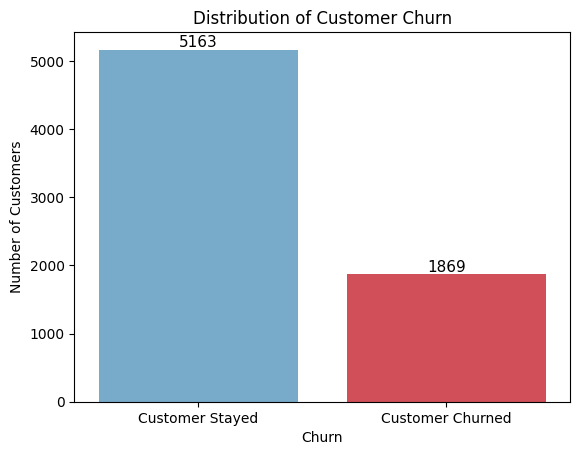

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(
    x="churn",
    hue="churn",
    data=df_encoded,
    palette=["#6BAED6", "#E63946"],
    legend=False
)

ax.set_xticklabels(["Customer Stayed", "Customer Churned"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### 1.4.1 Handling Class Imbalance (Optional)

In [16]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [17]:
from src.preprocessing import split_data, apply_smote, scale_data

X_train, X_test, y_train, y_test = split_data(df_encoded)

X_train_resampled, y_train_resampled = apply_smote(X_train, y_train)

X_train_scaled, X_test_scaled = scale_data(X_train_resampled, X_test)

In [18]:
print("Original training distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Original training distribution:
churn
0    3614
1    1308
Name: count, dtype: int64

After SMOTE:
churn
1    3614
0    3614
Name: count, dtype: int64


### 1.5 Feature Scaling for Machine Learning Models

In [19]:
import warnings
warnings.filterwarnings("ignore")

# Logistic Regression + GridSearch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_log = {
    'log_reg__C': [0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l2'],
    'log_reg__solver': ['lbfgs', 'saga']
}

grid_log = GridSearchCV(log_reg_pipeline, param_grid_log, cv=5, scoring='f1')
grid_log.fit(X_train_resampled, y_train_resampled)

print('Best parameters - Logistic Regression:', grid_log.best_params_)

Best parameters - Logistic Regression: {'log_reg__C': 0.01, 'log_reg__penalty': 'l2', 'log_reg__solver': 'lbfgs'}


Model Performance Metrics:
Accuracy: 0.7682
Precision: 0.5496
Recall: 0.7112
F1-score: 0.6200

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1549
           1       0.55      0.71      0.62       561

    accuracy                           0.77      2110
   macro avg       0.72      0.75      0.73      2110
weighted avg       0.79      0.77      0.78      2110



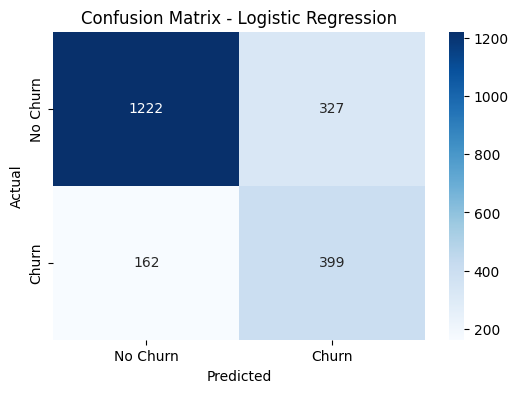

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

# Predictions on the test dataset
y_pred = grid_log.predict(X_test)

# Main evaluation metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Insights

Due to the class imbalance in the dataset, accuracy alone is not sufficient to properly evaluate model performance.

Therefore, additional metrics such as Precision, Recall, and F1-score were analyzed, as they provide a more complete understanding of the model’s ability to correctly identify customers who are likely to churn.

**The model achieved a recall of approximately 0.71 for the churn class**, indicating that it is capable of identifying a significant portion of customers at risk of leaving.

___
## 2. Correlation and Feature Selection

### 2.1 Correlation Analysis

In [21]:
# Numerical variables selected for correlation analysis
numerical_cols = [
    'tenure',
    'charges_monthly',
    'charges_total'
]

# Correlation matrix
corr_matrix = df_encoded[numerical_cols + ['churn']].corr()

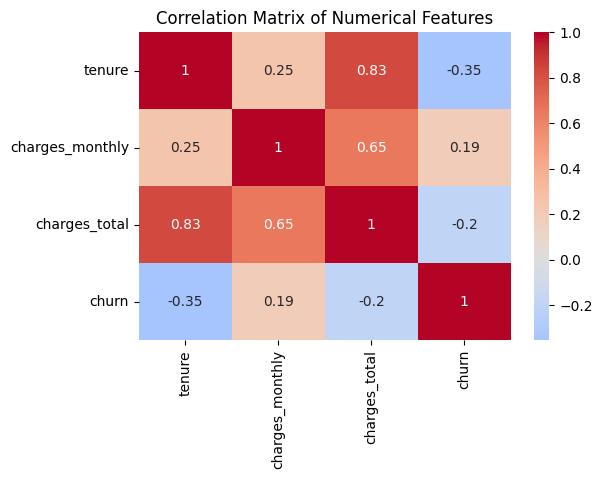

In [22]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### 2.2 Targeted Analysis of Key Variables

### 2.2.1 Contract Tenure × Churn

In [23]:
df_encoded["Churn Status"] = df_encoded["churn"].map({0:"Customer Stayed", 1:"Customer Churned"})

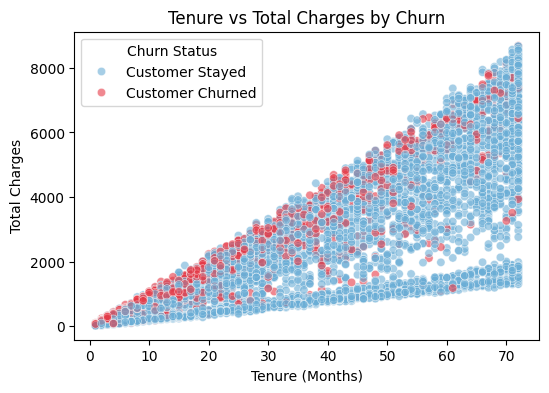

In [24]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="tenure",
    y="charges_total",
    hue="Churn Status",
    data=df_encoded,
    palette=["#6BAED6", "#E63946"],
    alpha=0.6
)

plt.title("Tenure vs Total Charges by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")

plt.show()

### 2.2.2 Total Charges × Churn

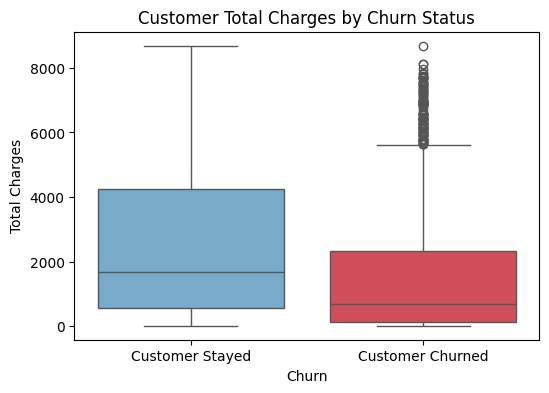

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn Status",
    y="charges_total",
    data=df_encoded,
    palette=[ "#6BAED6", "#E63946"]
)

plt.title("Customer Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

### Insights

Customers who churn tend to have shorter tenure and lower total charges compared to customers who remain active.

This pattern suggests that many cancellations occur during the early stages of the customer lifecycle.

Therefore, customer retention strategies should focus particularly on new customers in their first months of service.

___
## 🤖 Predictive Modeling

### 3.1 Data Splitting

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df_encoded.drop(["churn", "Churn Status"], axis=1)
y = df_encoded["churn"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [29]:
print("Full dataset distribution:")
print(y.value_counts(normalize=True))

print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))

Full dataset distribution:
churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Training set distribution:
churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Test set distribution:
churn
0    0.734123
1    0.265877
Name: proportion, dtype: float64


### 3.2 Model Creation
> In this stage, different machine learning models were developed to predict customer churn. 
> Two algorithms were selected to compare their performance and understand how different modeling approaches behave with the dataset.

### 3.2.1 Model 1 — Logistic Regression

Logistic Regression was selected as the first model because it is widely used for binary classification problems.

Since this algorithm is sensitive to feature scale, normalization was applied to ensure that all variables contribute equally to the model.

In [30]:
from src.train_model import train_logistic_regression

log_model = train_logistic_regression(X_train_scaled, y_train_resampled)
y_pred_log = log_model.predict(X_test_scaled)

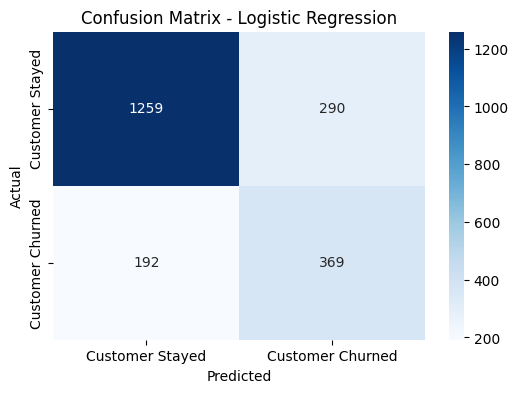

In [31]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Customer Stayed", "Customer Churned"],
    yticklabels=["Customer Stayed", "Customer Churned"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 3.2.2 Model 2 — Random Forest

Random Forest was selected as the second predictive model. This algorithm is an ensemble learning method that combines multiple decision trees to improve prediction performance.

Unlike Logistic Regression, Random Forest is not sensitive to feature scaling because it is based on decision trees that split data according to feature thresholds.

This allows the model to capture complex and non-linear relationships in the dataset without requiring normalization.

In [32]:
from src.train_model import train_random_forest

rf_model = train_random_forest(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

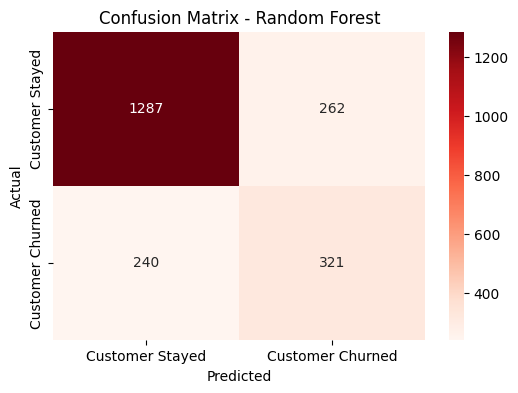

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Customer Stayed", "Customer Churned"],
    yticklabels=["Customer Stayed", "Customer Churned"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 3.2.3 Model Evaluation

In [40]:
from src.evaluate_model import evaluate_model

log_results = evaluate_model(log_model, X_test_scaled, y_test)
rf_results = evaluate_model(rf_model, X_test, y_test)

print("=== Accuracy ===")
print("Logistic Regression:", log_results["accuracy"])
print("Random Forest:", rf_results["accuracy"])

print("\n=== Classification Report ===")

print("\nLogistic Regression:")
print(log_results["report"])

print("\nRandom Forest:")
print(rf_results["report"])

=== Accuracy ===
Logistic Regression: 0.771563981042654
Random Forest: 0.762085308056872

=== Classification Report ===

Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1549
           1       0.56      0.66      0.60       561

    accuracy                           0.77      2110
   macro avg       0.71      0.74      0.72      2110
weighted avg       0.79      0.77      0.78      2110


Random Forest:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1549
           1       0.55      0.57      0.56       561

    accuracy                           0.76      2110
   macro avg       0.70      0.70      0.70      2110
weighted avg       0.77      0.76      0.76      2110



**Logistic Regression achieved better performance** in detecting churn cases, showing higher recall for the churn class.

Random Forest produced slightly more conservative predictions, resulting in fewer churn detections but also fewer false positives.

Overall, the results suggest that churn behavior in this dataset follows relatively linear patterns related to contract duration and billing characteristics. Because of this, Logistic Regression slightly outperformed Random Forest, as these relationships can be effectively captured by a linear model.

## 3.2.4 ROC Curve

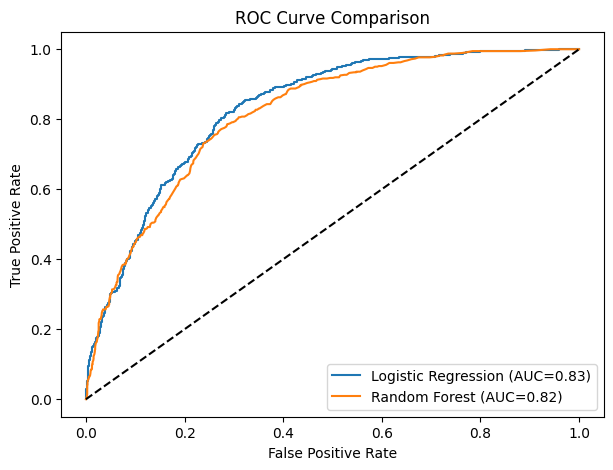

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# AUC
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### ROC Curve Analysis

Both models demonstrated good predictive performance, with AUC scores above 0.80.

Logistic Regression achieved a slightly higher AUC (0.83) compared to Random Forest (0.82), indicating a marginally better ability to distinguish between customers who churn and those who remain.

Overall, the results suggest that both models are effective for churn prediction, with Logistic Regression providing slightly stronger discrimination.

### Overfitting and Underfitting

No clear signs of overfitting or underfitting were observed. Both models achieved similar performance on the test data, indicating that they generalize reasonably well to unseen observations.

Logistic Regression showed slightly better performance, with a marginally higher AUC score and better detection of churn cases.

Random Forest produced comparable results, although with slightly lower performance. This may be related to the use of default hyperparameters, and further tuning could potentially improve the model.

___
## 4. Feature Importance Analysis

## 4.1 Logistic Regression Feature Importance

In [36]:
import pandas as pd

log_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_importance["Abs_Coefficient"] = log_importance["Coefficient"].abs()

log_importance = log_importance.sort_values(by="Abs_Coefficient", ascending=False)

log_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
13,charges_monthly,6.511741,6.511741
16,internetservice_Fiber optic,-2.465636,2.465636
3,tenure,-1.938839,1.938839
17,internetservice_No,1.818172,1.818172
4,phoneservice,-1.652167,1.652167
14,charges_total,1.525712,1.525712
11,streamingmovies,-1.093260,1.093260
10,streamingtv,-1.023276,1.023276
9,techsupport,-0.754830,0.754830
6,onlinesecurity,-0.732226,0.732226


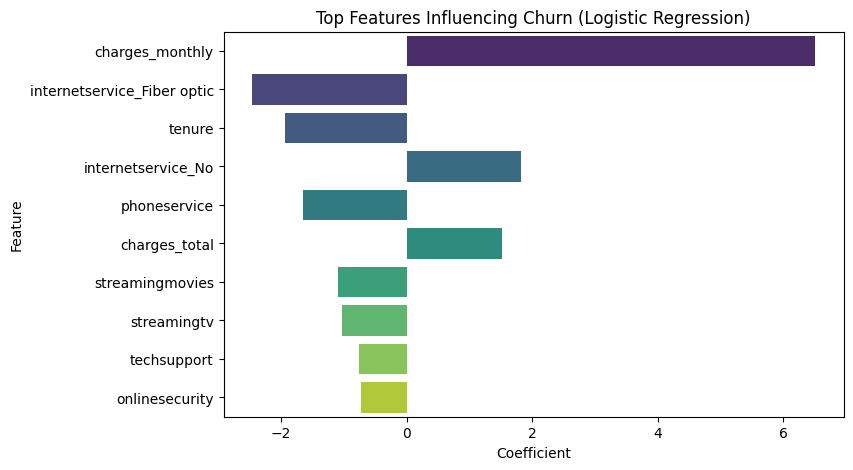

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=log_importance.head(10),
    palette="viridis"
)

plt.title("Top Features Influencing Churn (Logistic Regression)")
plt.show()

## 4.2 Random Forest Feature Importance

In [38]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
13,charges_monthly,0.151720
14,charges_total,0.143105
3,tenure,0.139322
19,contract_Two year,0.071250
18,contract_One year,0.045846
6,onlinesecurity,0.043555
9,techsupport,0.041829
16,internetservice_Fiber optic,0.040566
1,partner,0.035607
2,dependents,0.035439


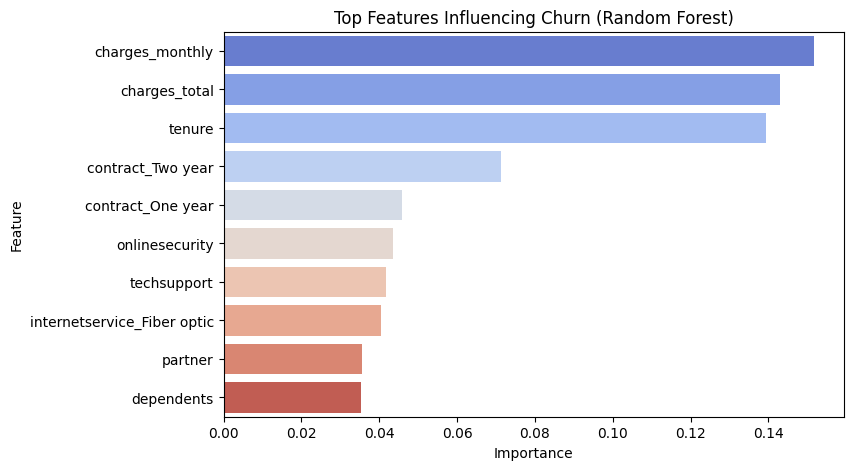

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(10),
    palette="coolwarm"
)

plt.title("Top Features Influencing Churn (Random Forest)")
plt.show()

### Key Insights

The feature importance analysis revealed that variables related to tenure, total charges, and monthly charges play a significant role in predicting customer churn.

Customers with shorter tenure and higher service costs tend to have a higher probability of leaving the service. Contract type also plays an important role, as longer contracts significantly reduce the likelihood of churn.

These insights can help companies design targeted retention strategies for customers who show higher churn risk.

___
## 📌 Conclusion – TelecomX Churn Prediction

In this project, the exploratory analysis conducted in Part 1 was extended by developing predictive models to identify customers with a higher risk of churn. The goal was to transform descriptive insights into predictive solutions that support data-driven decision making.

The results confirmed previous findings that financial and time-related variables are the main drivers of customer churn. Customer tenure, total charges, and monthly charges were identified as the most influential variables across the evaluated models.

Among the models tested, Logistic Regression achieved slightly better performance, demonstrating a strong ability to generalize to unseen data. Random Forest also performed well, producing comparable results, although the dataset appears to follow relatively linear patterns that are effectively captured by Logistic Regression.

### 🎯 Strategic Recommendations

Based on the analysis, the following strategies could help reduce customer churn:

* Focus retention efforts on customers in the early months of their contracts;

* Encourage long-term contracts through incentives or loyalty benefits;

* Monitor customers with higher monthly charges who may present greater churn risk;

* Promote automatic payment methods to improve customer retention;

* Integrate predictive models into decision-making processes to proactively identify customers at risk.

By combining exploratory analysis with predictive modeling, this project demonstrates how data can be transformed into strategic insights that support customer retention and improve long-term business performance.